In [3]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
from matplotlib.colors import LinearSegmentedColormap, Normalize  
from matplotlib import rcParams  


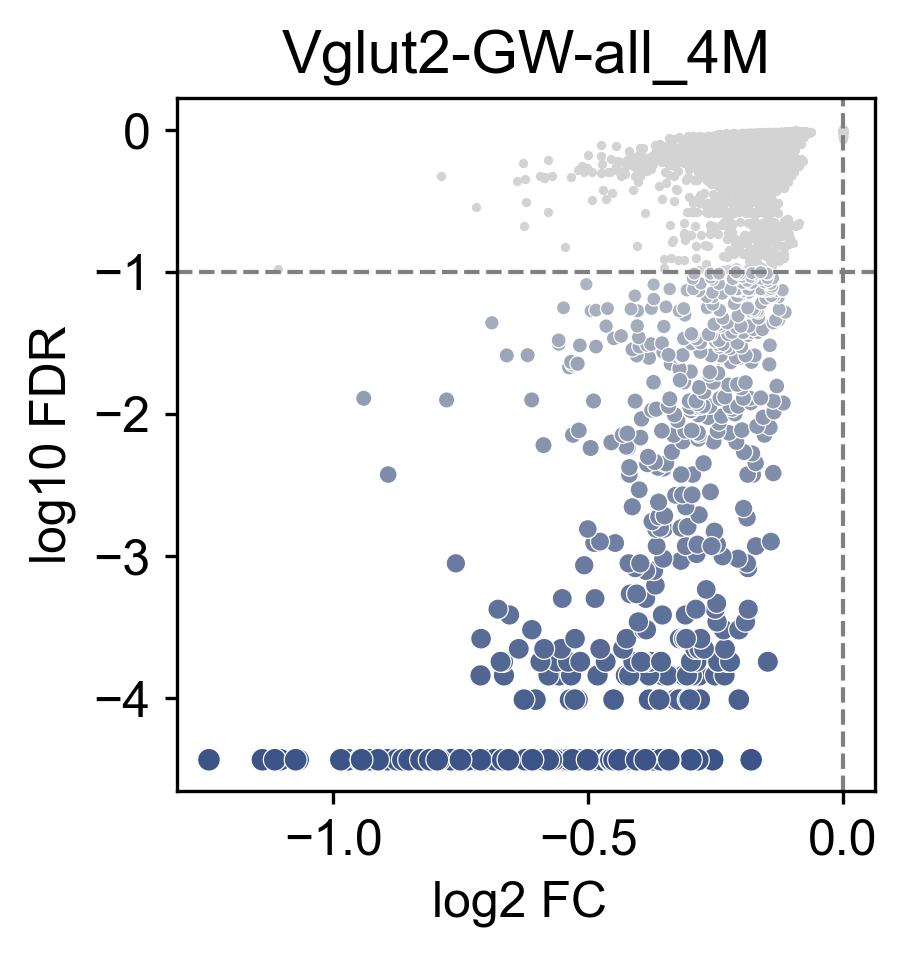

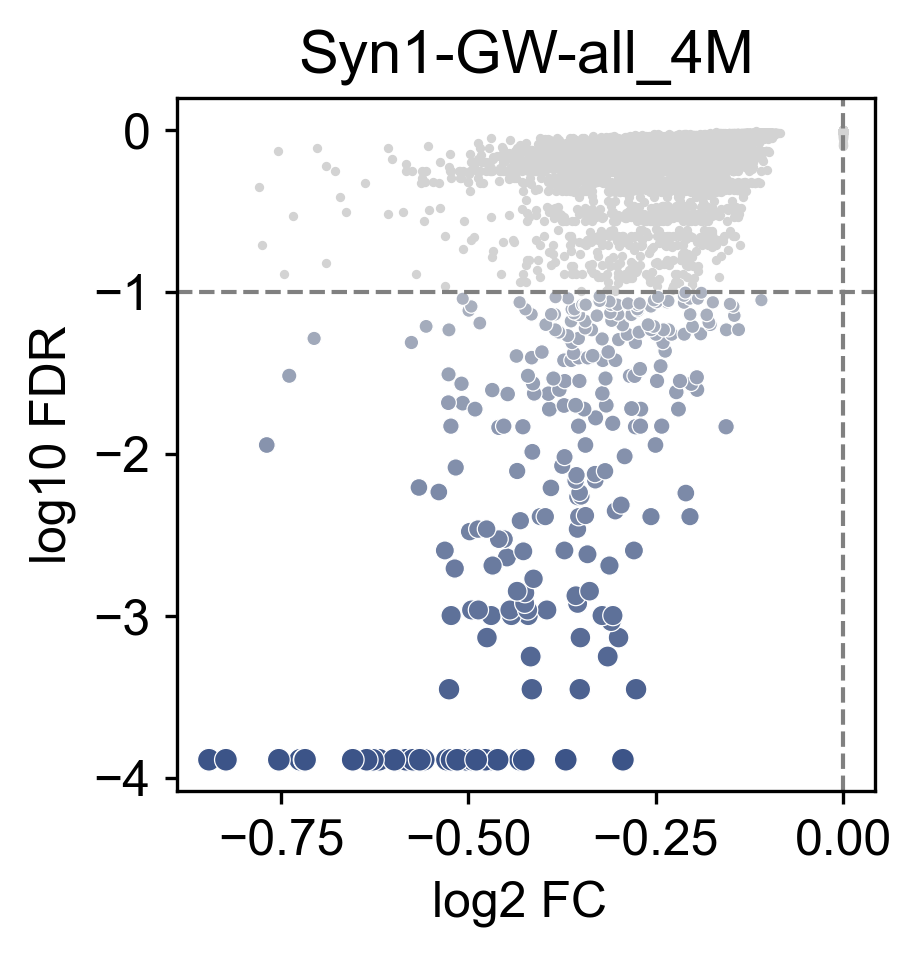

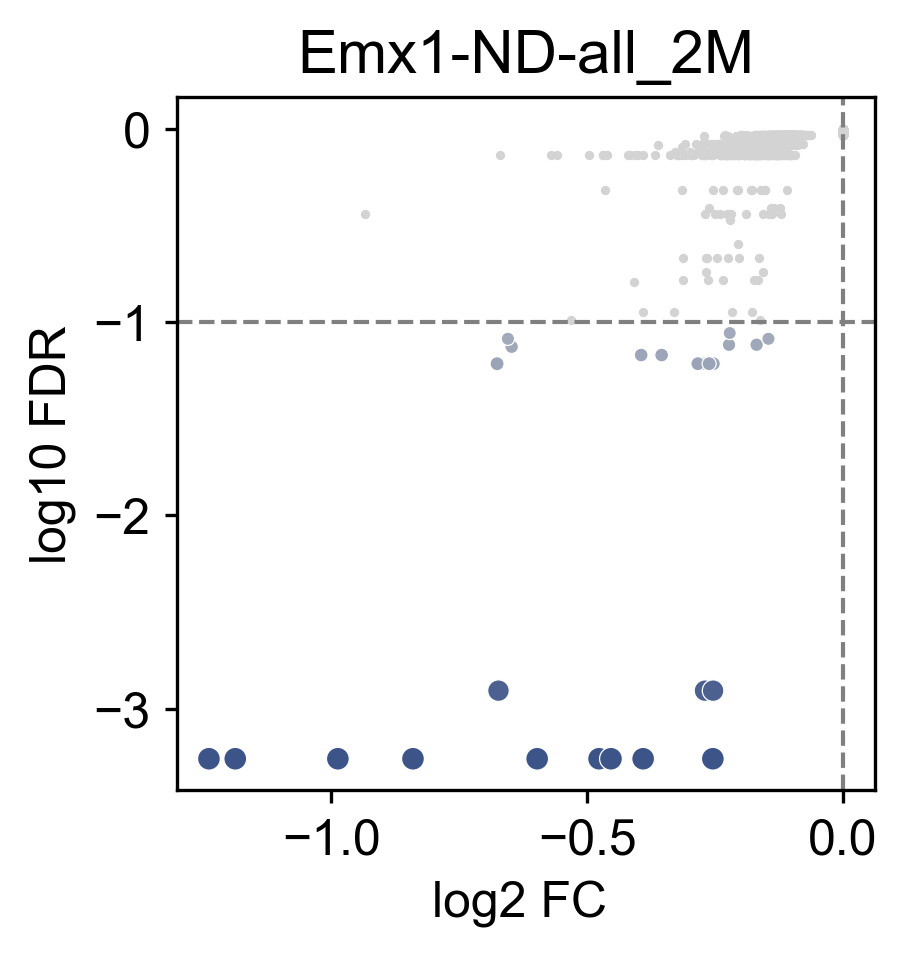

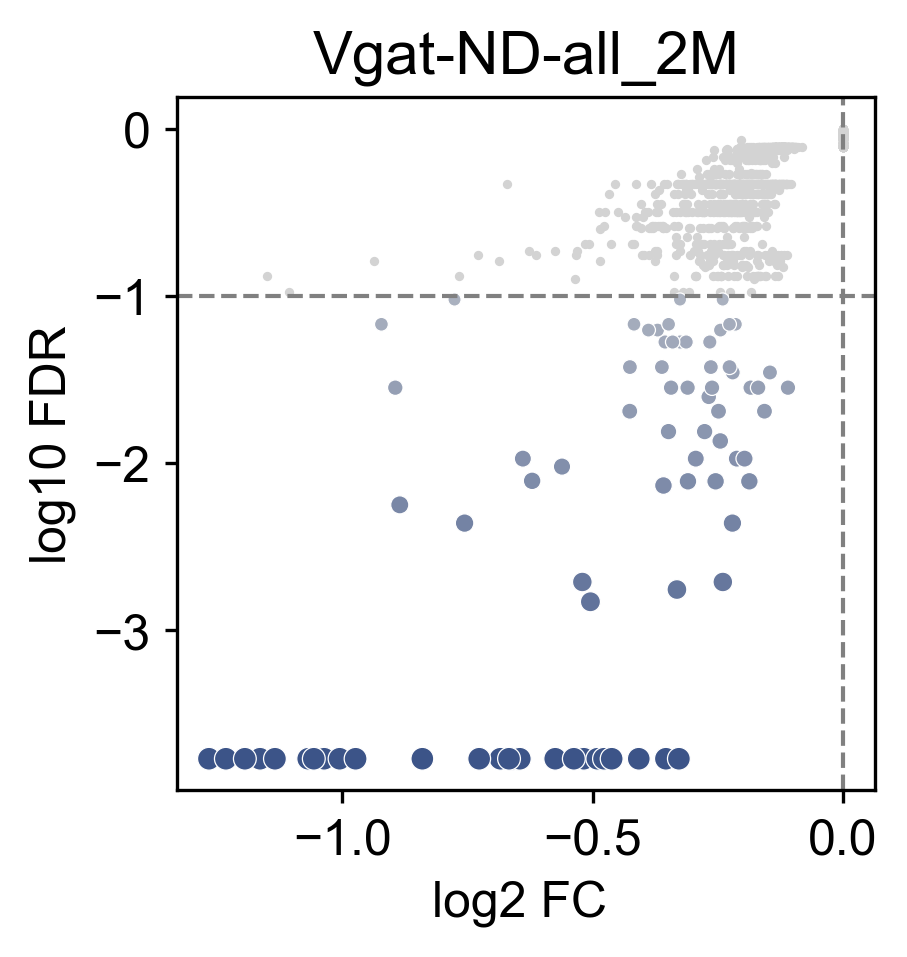

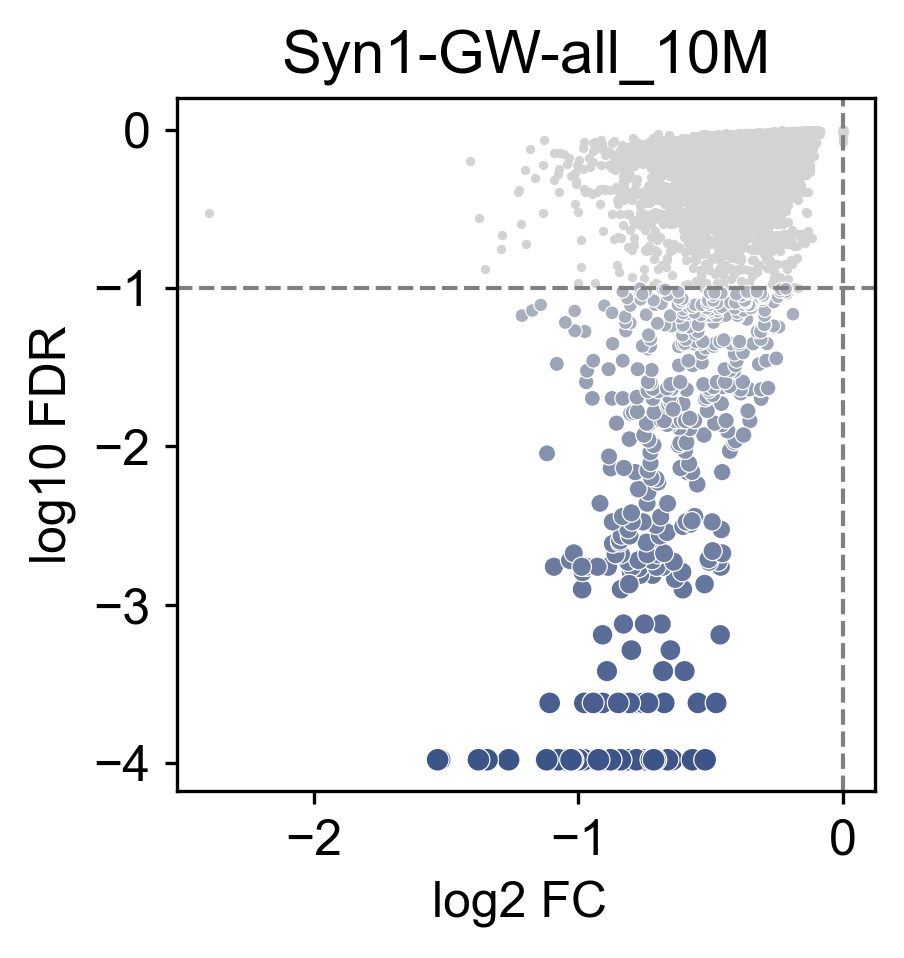

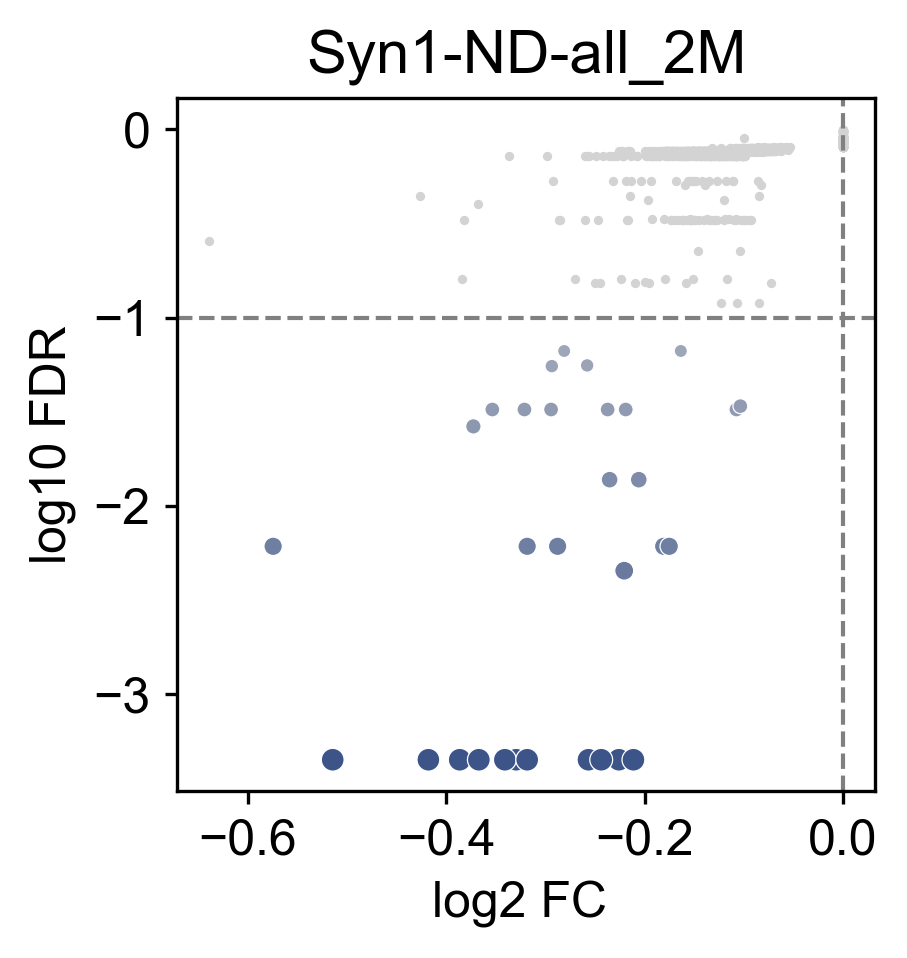

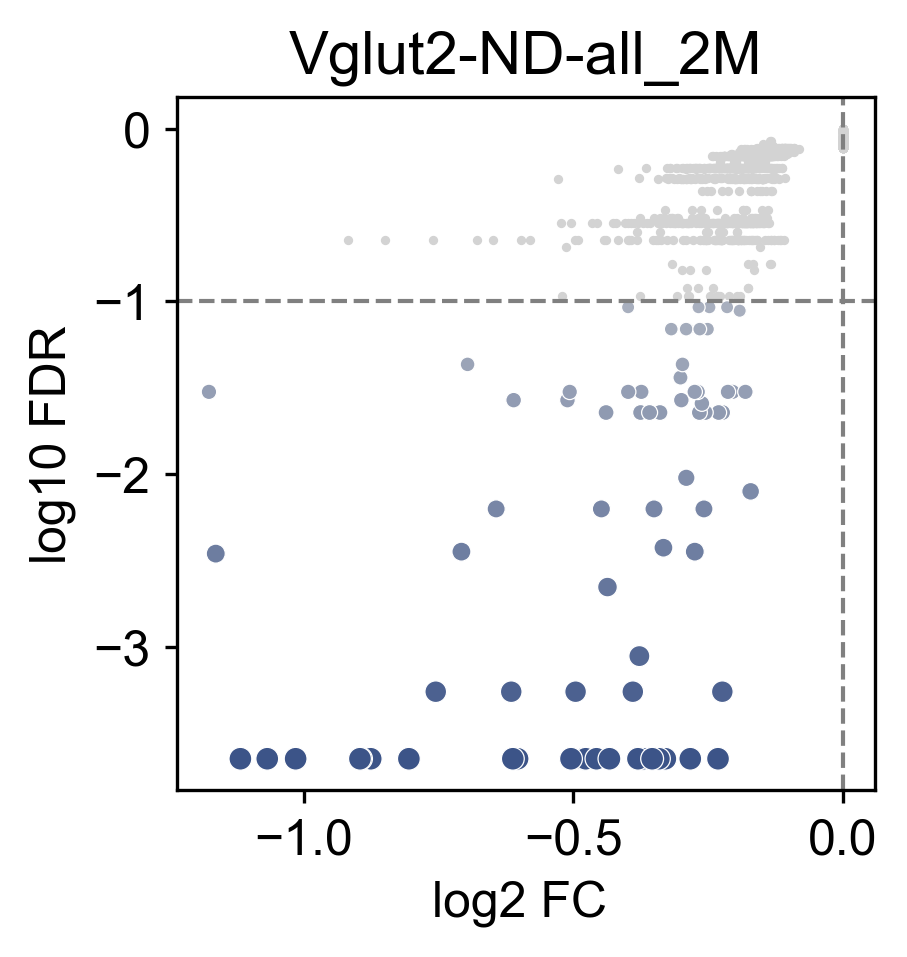

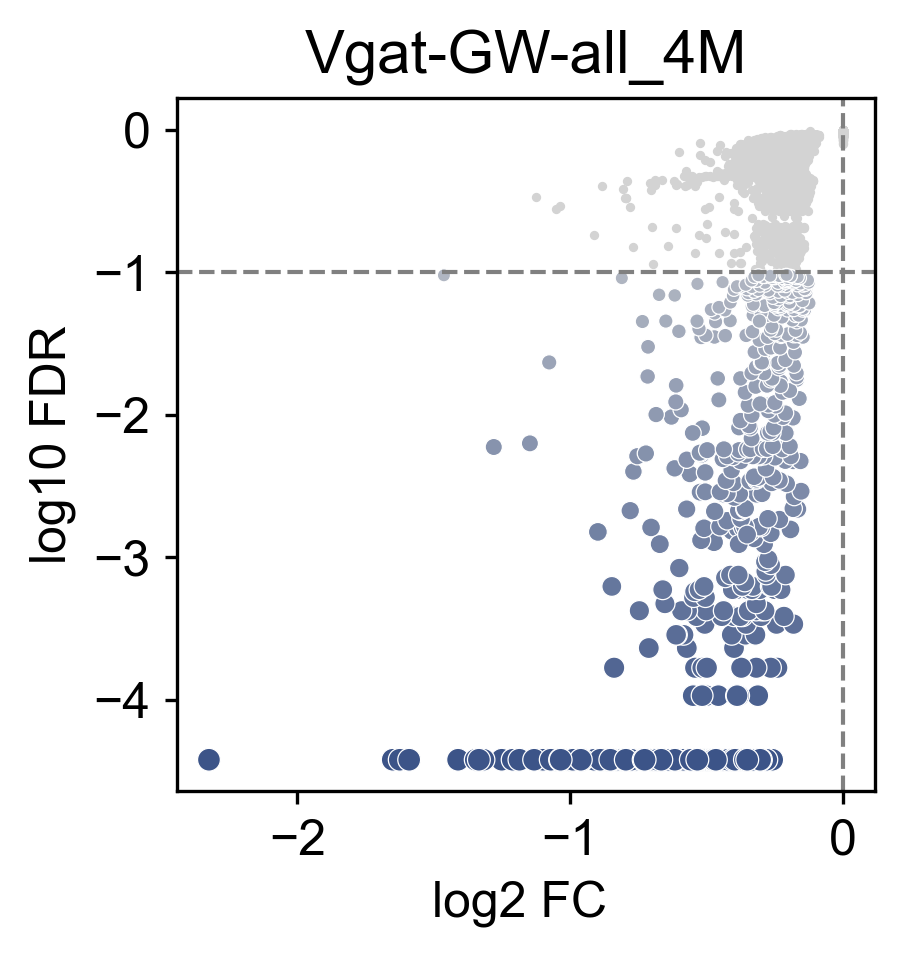

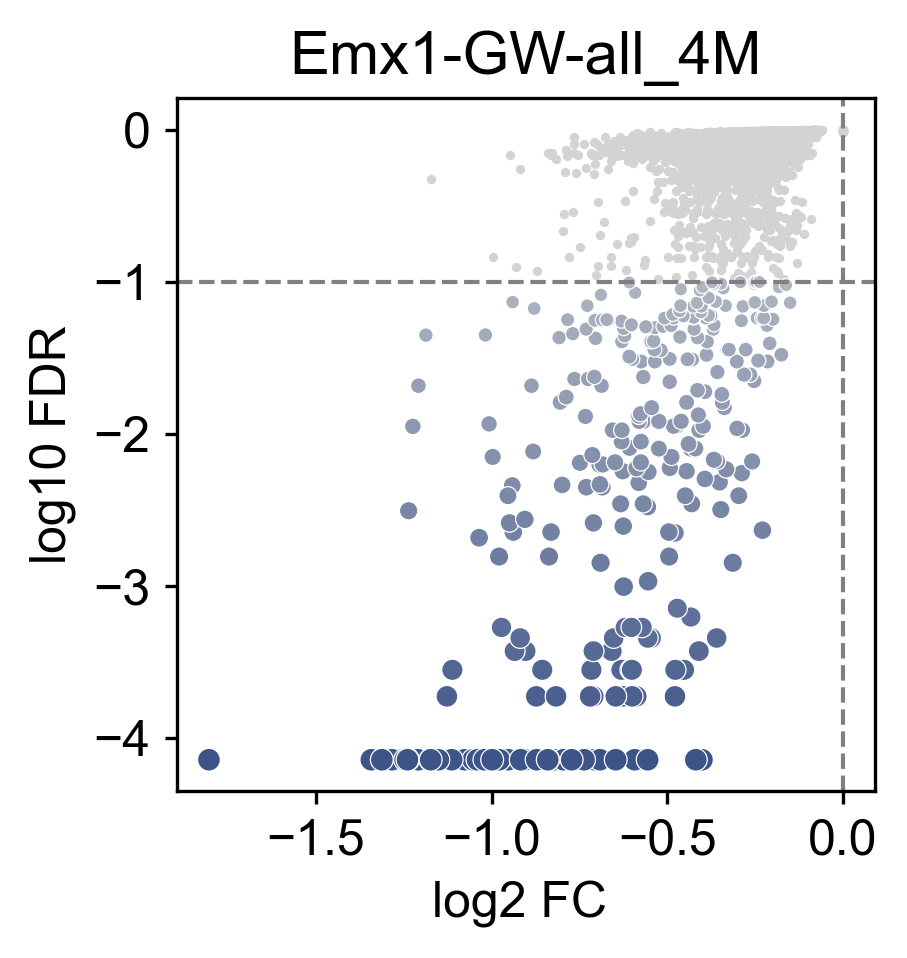

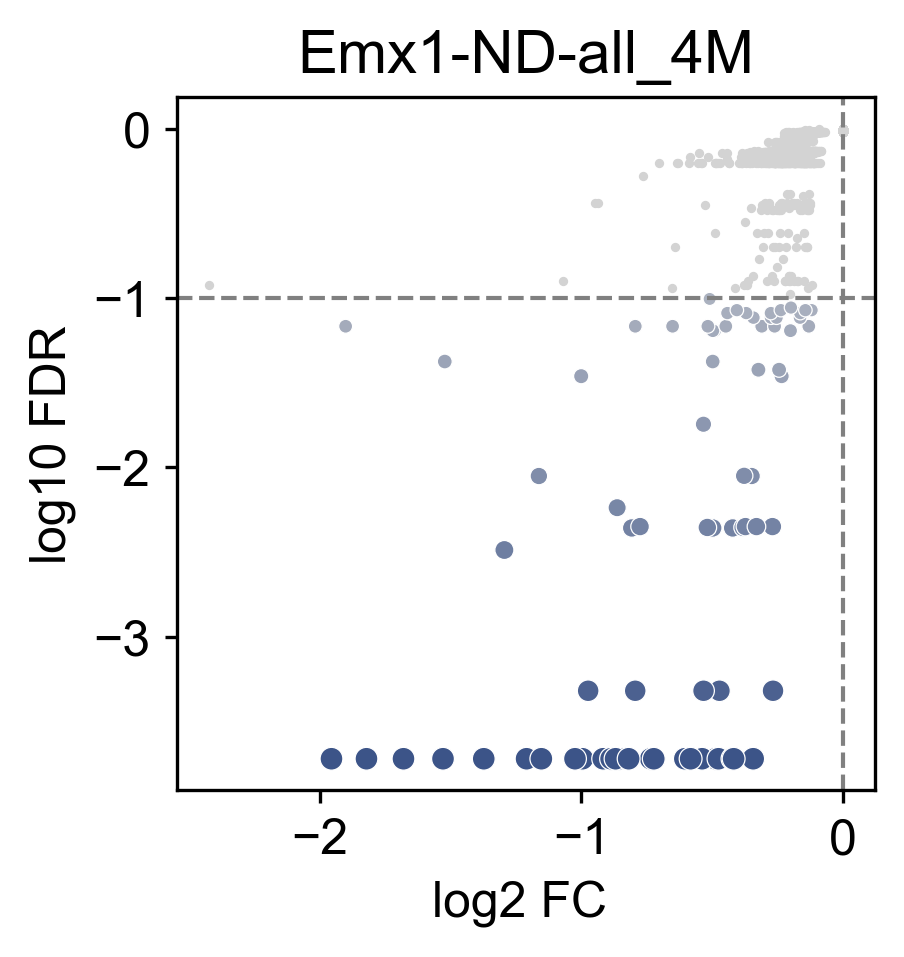

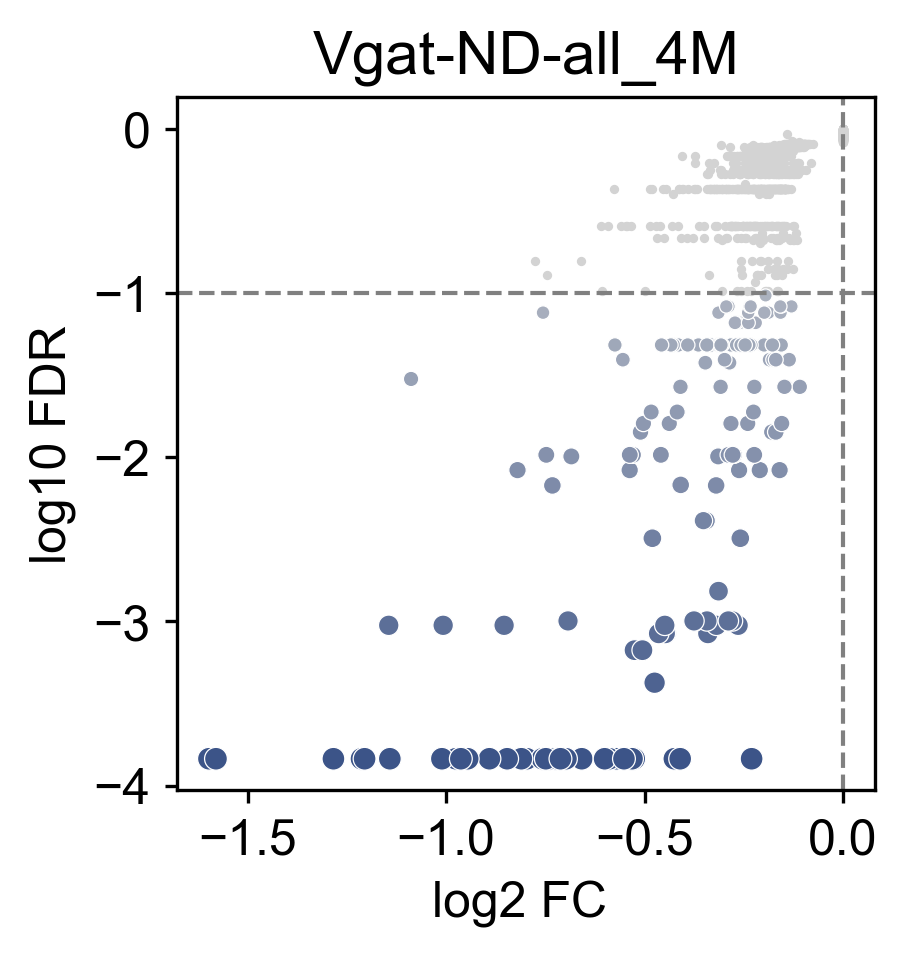

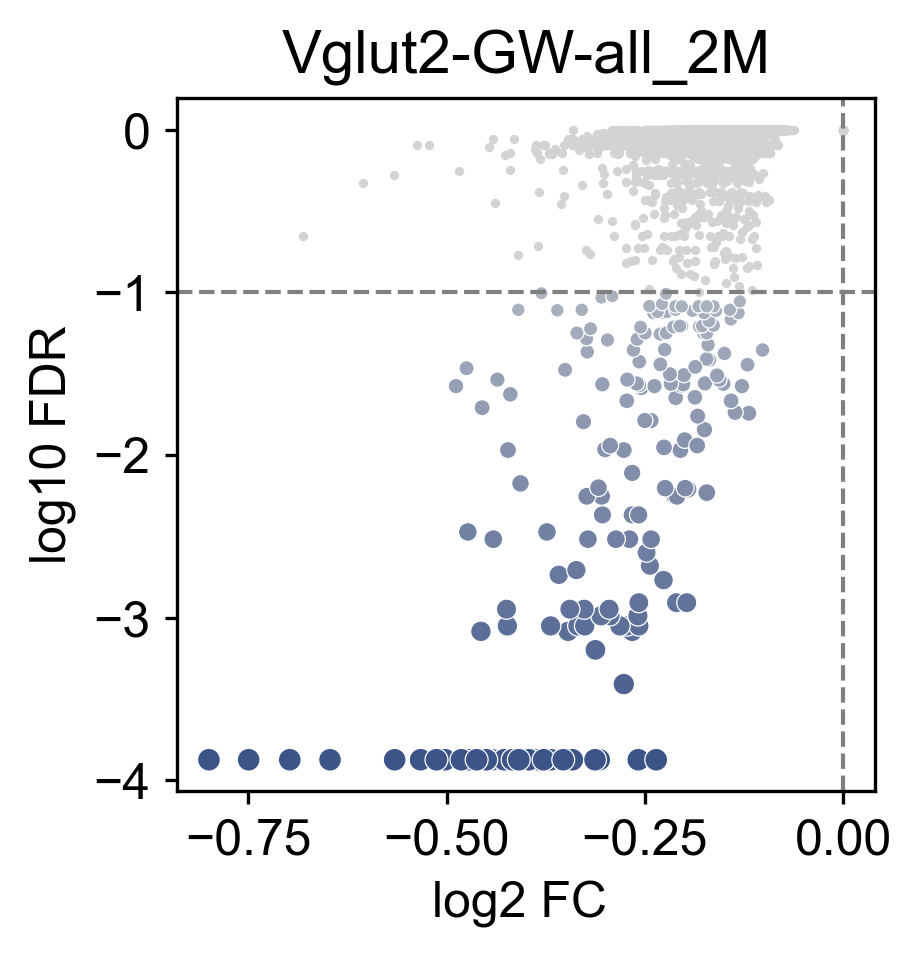

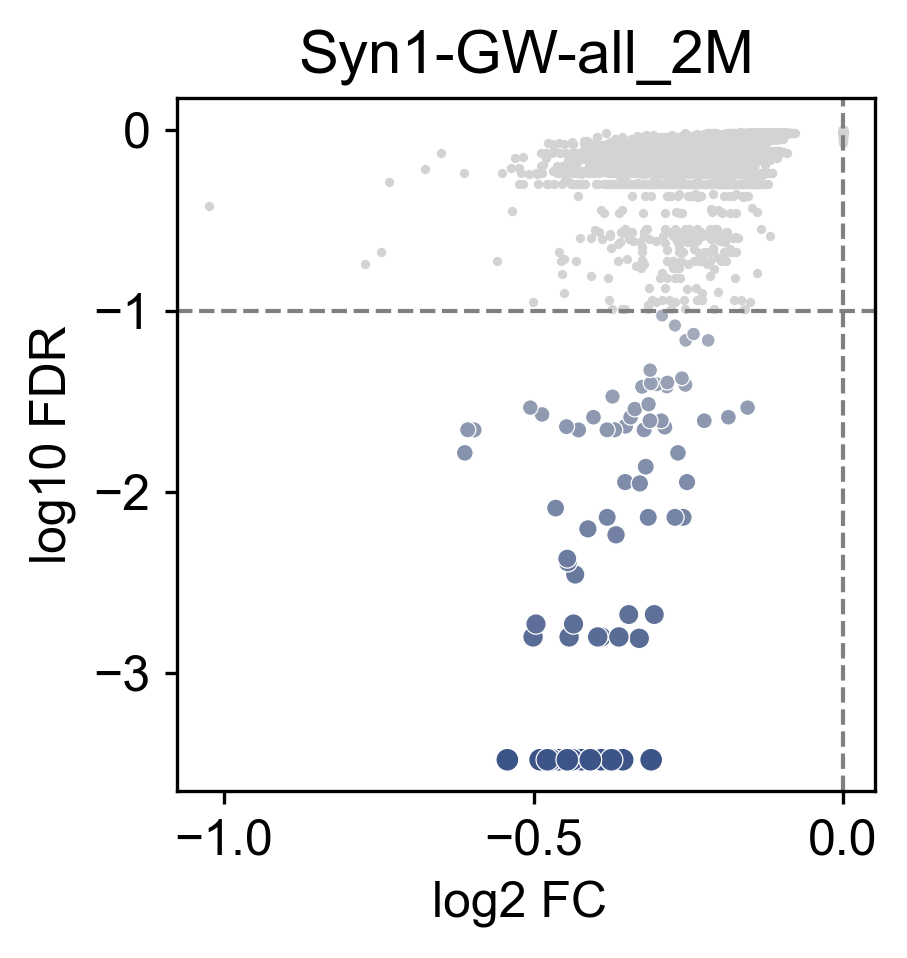

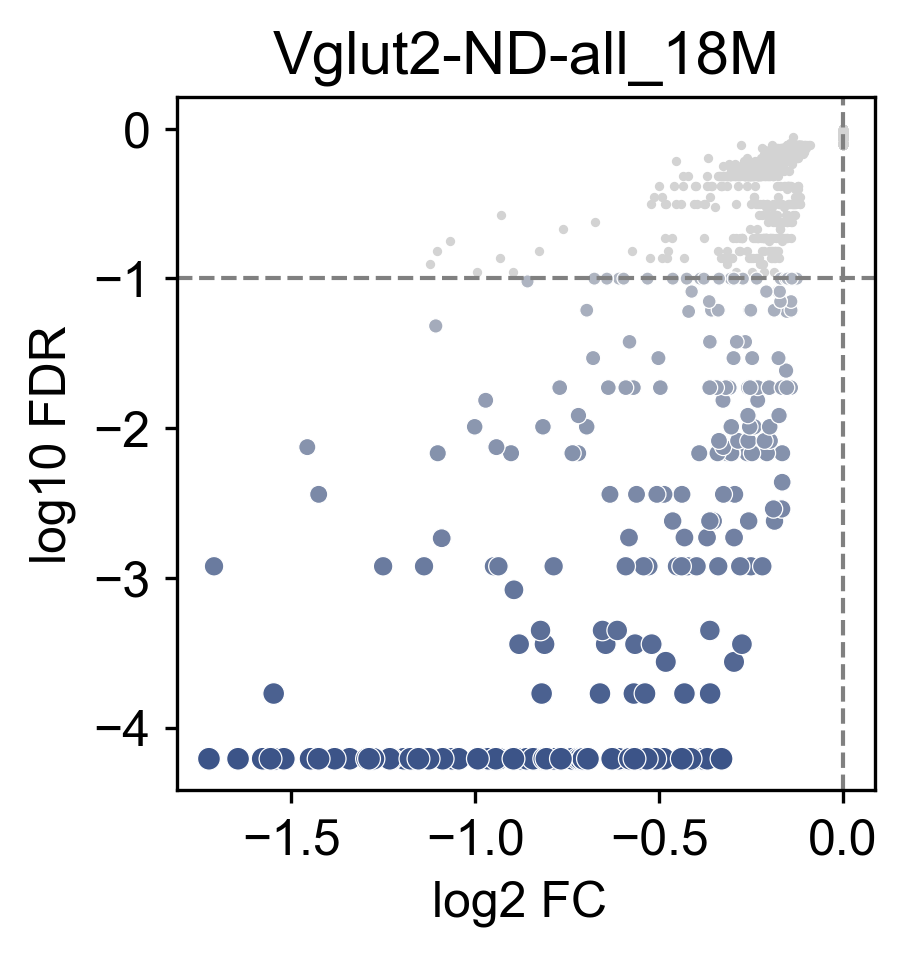

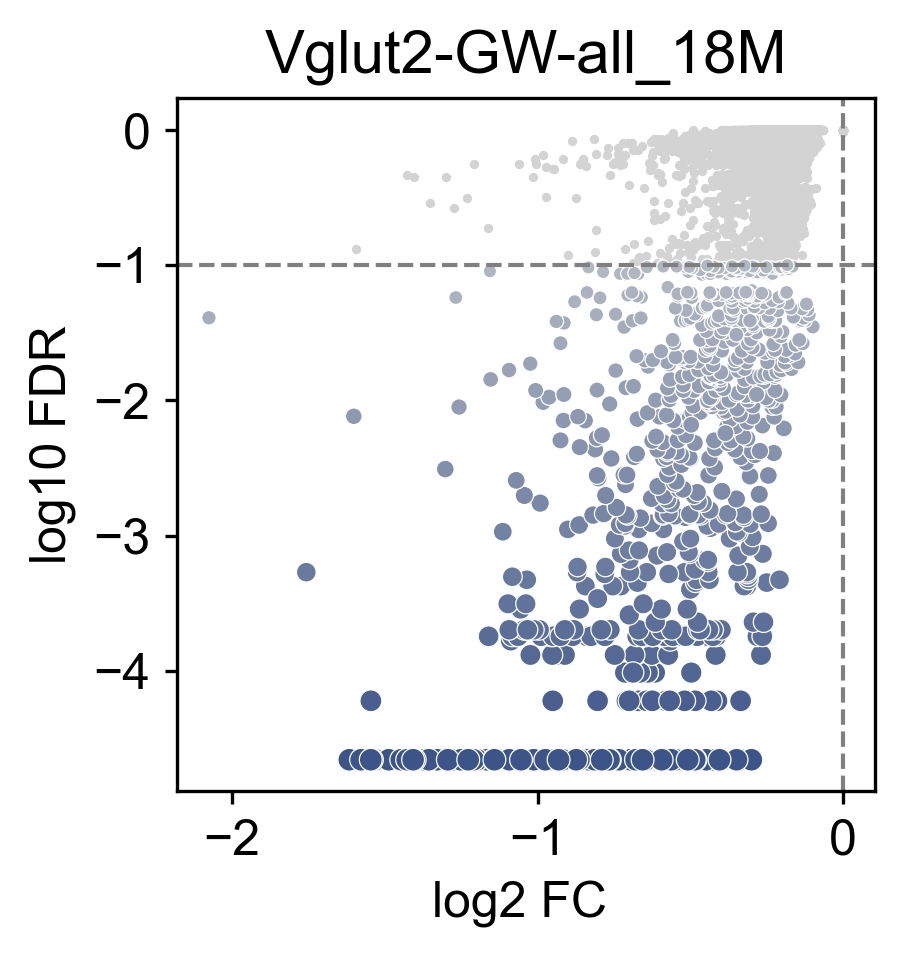

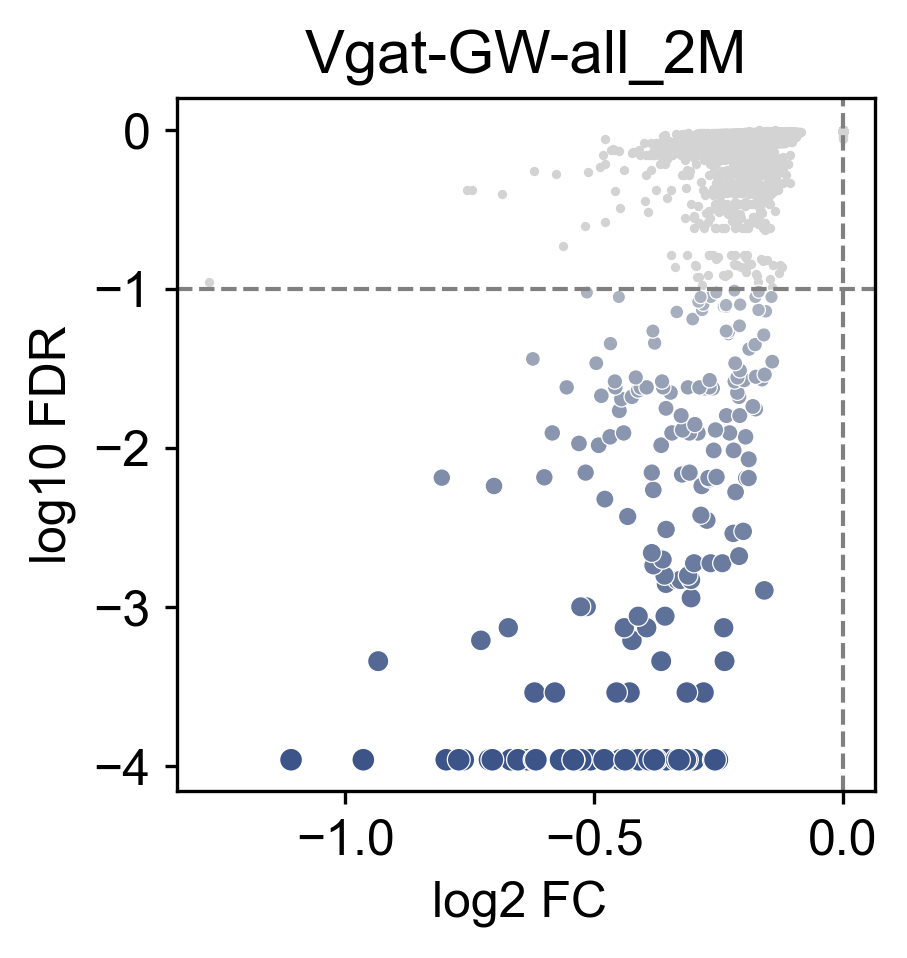

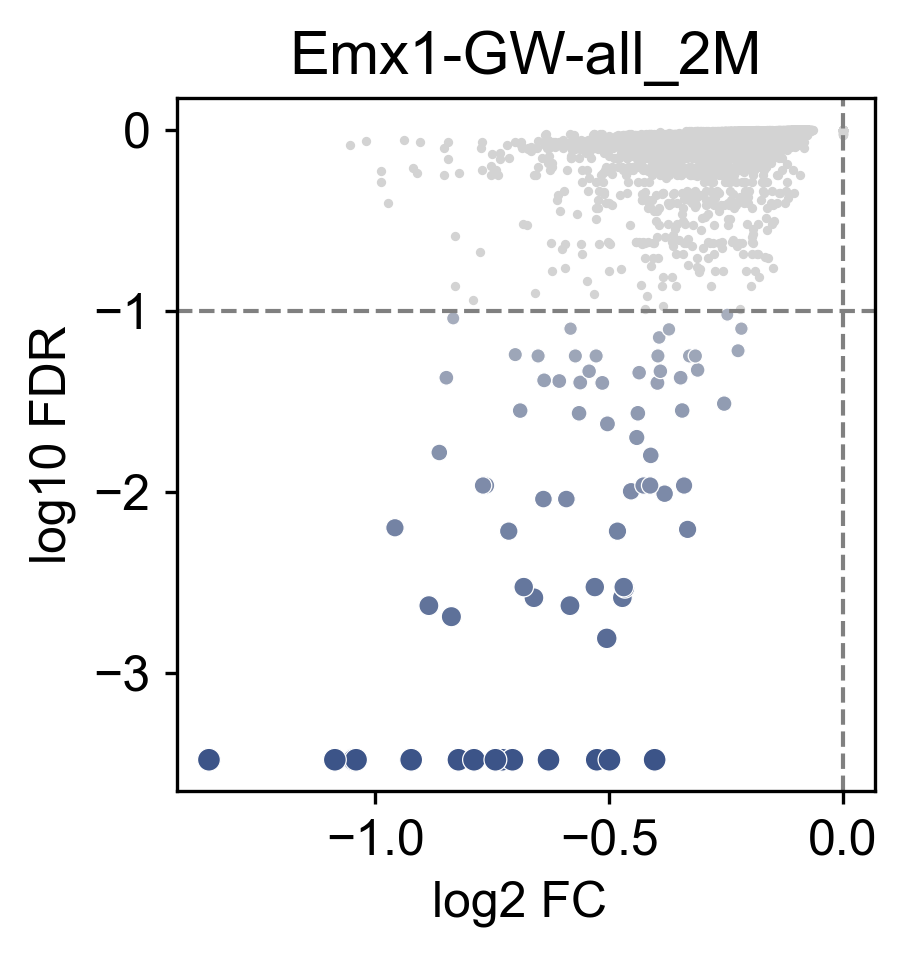

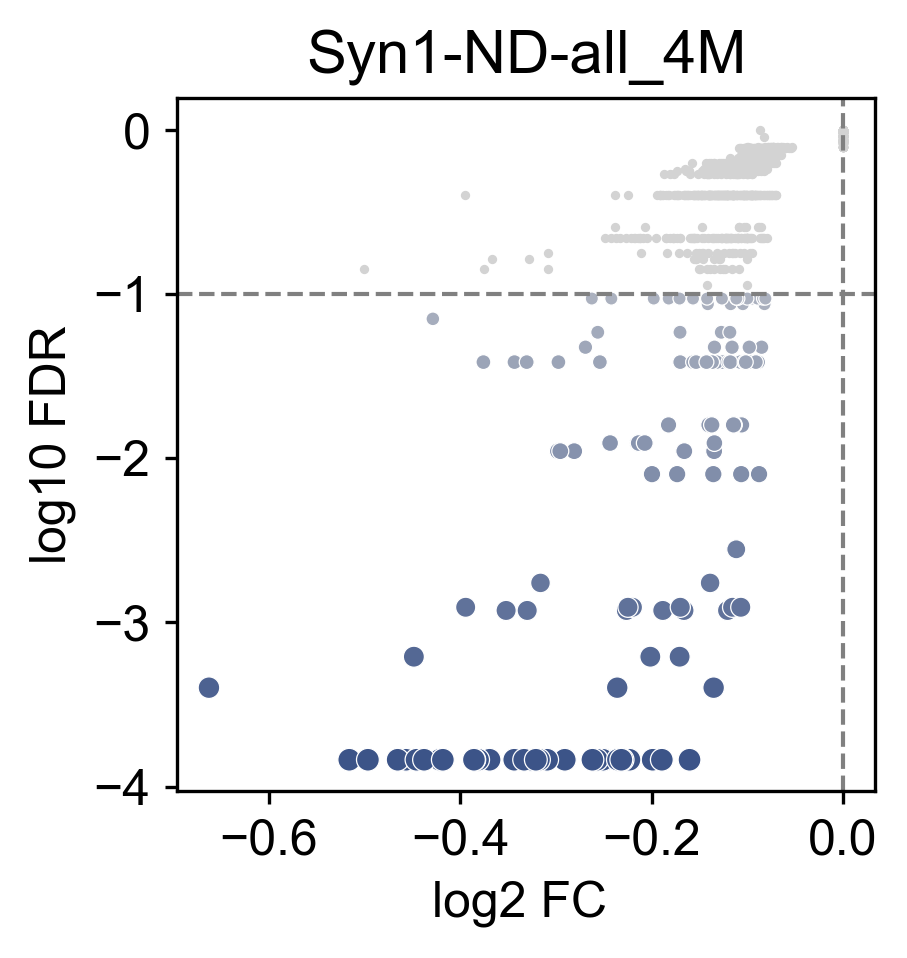

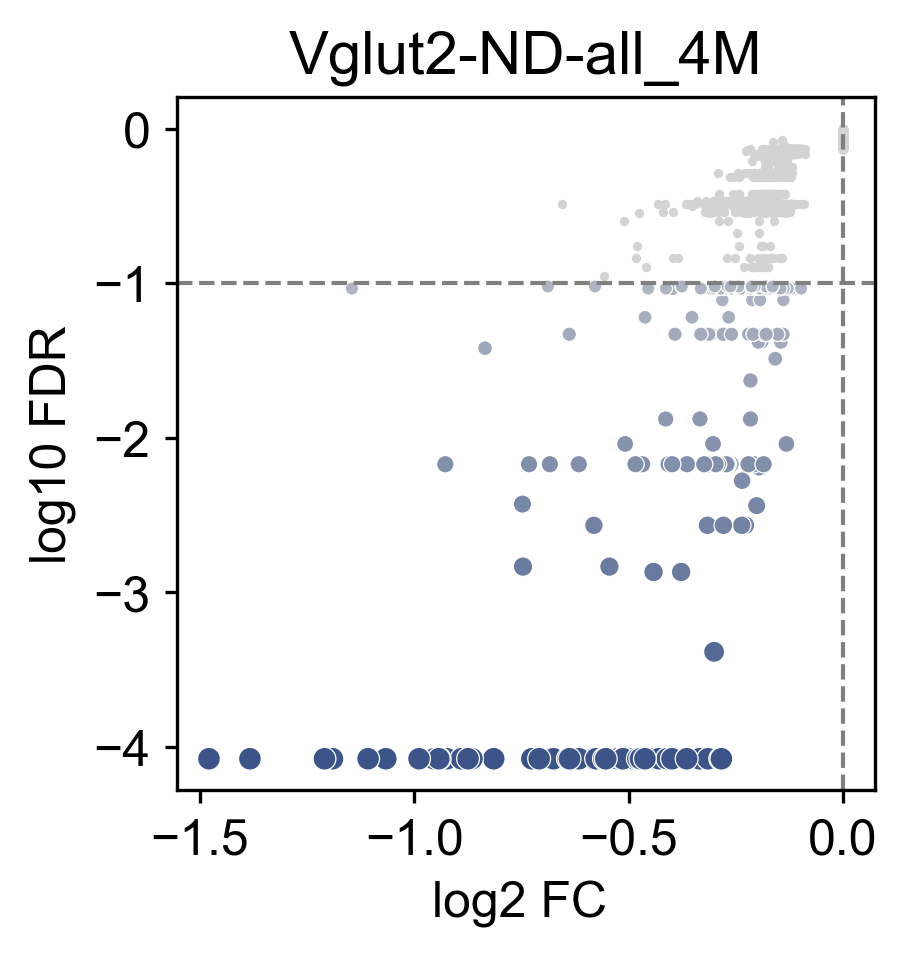

In [5]:
# ---- Load MAGeCK results ----  

import os
for sample in os.listdir('../new_mageck/'):
    if not sample.startswith('.'):
        gene_summary_path = f'../new_mageck/{sample}/{sample}.gene_summary.txt'  # set your file path here  
        df = pd.read_csv(gene_summary_path, sep='\t', comment='#')  
        df_hits = df[(df['hits']==-1) & (df['neg|lfc']<0)]
        
        cell_blue = "#3C5488FF"  
        cell_orange = "#f9a65a"  
        cell_text = "k"  
        cell_gray = "#bbb" 
        cell_red = '#DC0000FF'

        rcParams['font.family'] = 'sans-serif'  
        rcParams['font.sans-serif'] = ['Arial']  
        rcParams['font.size'] = 12 
        rcParams['axes.linewidth'] = 0.8  
        rcParams['xtick.major.width'] = 0.8  
        rcParams['ytick.major.width'] = 0.8  
        rcParams['xtick.major.size'] = 3  
        rcParams['ytick.major.size'] = 3  
        rcParams['pdf.fonttype'] = 42  # Ensures text is editable in AI  
        rcParams['ps.fonttype'] = 42  
        rcParams['svg.fonttype'] = 'none'  
        rcParams['figure.dpi'] = 300  

        # ---- 1. VOLCANO PLOT ----  
        fig, ax = plt.subplots(figsize=(3,3), dpi=300)  


           


        min_size, max_size = 10, 30
        abs_lfc = (-np.log10(df_hits['neg|fdr']))
        sizes = np.interp(-np.log10(df_hits['neg|fdr']),  
                          (abs_lfc.min(), abs_lfc.max()),  
                          (min_size, max_size)) 


        cmap = LinearSegmentedColormap.from_list(  
            'cmap',  
            ['lightgrey', cell_blue]  
        )  

        norm = Normalize(  
            vmax=-np.log10(df['neg|fdr']).min(),  
            vmin=-np.log10(df['neg|fdr']).max() )
       

        ax.scatter(  
            df['neg|lfc'],  
            np.log10(df['neg|fdr']),  
            s=3,  
            c = 'lightgrey',
            alpha=1, 
            edgecolors='lightgrey',
            linewidths=0.5 
        )  
        

        ax.scatter(  
            df_hits['neg|lfc'],  
            np.log10(df_hits['neg|fdr']),  
            s=sizes,  
            c=-np.log10(df_hits['neg|fdr']),  
            cmap=cmap, norm = norm, 
            alpha=1,  
            edgecolors='white',
            linewidths=0.3
        )   

        ax.axhline(np.log10(0.1), color='gray', linestyle='--', lw=1) 
        ax.axvline(0, color='gray', linestyle='--', lw=1)  
        plt.xlabel('log2 FC ')
        plt.ylabel('log10 FDR')
        plt.title(sample)
        plt.savefig(f'../volcano_plots/{sample}_plot.pdf', bbox_inches = 'tight')
        plt.savefig(f'../volcano_plots/{sample}_plot.png', bbox_inches = 'tight', dpi = 300)